# Probabilistic Models & Bayesian Inference — Assignment Notebook
### Week 6 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right formula, prior, or model and justify why.

> **Datasets:**
> - **Telco Customer Churn** (Parts 1–4, 6): same CSV from Week 5
> - **Mauna Loa CO₂** (Part 5 only): `from statsmodels.datasets import co2` — 3 lines to load

---


In [57]:
!pip install -q pymc arviz pgmpy scikit-learn scipy statsmodels pandas numpy matplotlib seaborn


In [58]:
# Run this cell first — all imports and data loading happen here
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist, dirichlet

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, DotProduct
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pymc as pm
import arviz as az
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [12, 5]

# seaborn sets the color cycle as RGB tuples; arviz 1.1.0's az.plot_trace can't
# reshape those into per-chain colors. Convert to hex strings (identical colors).
import matplotlib.colors as _mcolors
from cycler import cycler as _cycler
plt.rcParams['axes.prop_cycle'] = _cycler(
    color=[_mcolors.to_hex(c) for c in plt.rcParams['axes.prop_cycle'].by_key()['color']])

# ── Telco data ─────────────────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Telco loaded: {df.shape}  Churn rate: {df['Churn'].mean():.3f}")


Telco loaded: (7043, 20)  Churn rate: 0.265


---
## Part 1: The Estimation Trinity — MLE, MAP, Full Bayes

**Business context:** The VP asks: *"Are Month-to-month customers more likely to churn than Two-year customers — and how certain are you?"* Three statistical frameworks give three different answers.

---

### Q1 — Extract the experimental groups

Extract Group A (Month-to-month), Group B (Two-year), and Group A_small (40 rows from A).


In [59]:
# Q1 — Extract groups
group_A = df[df['Contract'] == 'Month-to-month']
group_B = df[df['Contract'] == 'Two year']
group_A_small = group_A.sample(n=40, random_state=42)

k_A,  n_A  = group_A['Churn'].sum(),       len(group_A)
k_B,  n_B  = group_B['Churn'].sum(),       len(group_B)
k_As, n_As = group_A_small['Churn'].sum(), len(group_A_small)

assert n_As == 40
assert n_A > 3000
assert n_B > 1000
print(f"Group A  (M2M):  n={n_A}, k={k_A}, rate={k_A/n_A:.4f}")
print(f"Group A_small:   n={n_As}, k={k_As}, rate={k_As/n_As:.4f}")
print(f"Group B  (2yr):  n={n_B}, k={k_B}, rate={k_B/n_B:.4f}")
print("✅ Groups extracted correctly!")

Group A  (M2M):  n=3875, k=1655, rate=0.4271
Group A_small:   n=40, k=15, rate=0.3750
Group B  (2yr):  n=1695, k=48, rate=0.0283
✅ Groups extracted correctly!


### Q2 — Compute MLE, MAP, and plot all three posteriors

Use a **Beta(2, 8) prior** (encodes belief that most segments churn < 30%).


In [60]:
alpha_prior, beta_prior = 2, 8   # Beta(2, 8) prior — do not change

# YOUR CODE HERE — for each group compute:
#   mle     = k / n
#   map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
#   pull    = |map_est - mle|  (how far prior pulls MAP from MLE)

groups = {
    'Group A (M2M, large)': (k_A,  n_A),
    'Group A_small (n=40)': (k_As, n_As),
    'Group B (2yr, large)': (k_B,  n_B),
}

print(f"{'Group':<30} {'MLE':>8} {'MAP':>8} {'|MAP-MLE|':>12}")
print("-" * 62)

for name, (k, n) in groups.items():
    mle = k / n
    map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    pull = abs(map_est - mle)
    print(f"{name:<30} {mle:>8.4f} {map_est:>8.4f} {pull:>12.4f}")


Group                               MLE      MAP    |MAP-MLE|
--------------------------------------------------------------
Group A (M2M, large)             0.4271   0.4265       0.0006
Group A_small (n=40)             0.3750   0.3333       0.0417
Group B (2yr, large)             0.0283   0.0288       0.0005


In [64]:
# # YOUR CODE HERE — plot the three posterior PDFs on one figure
# # For each group: plot Prior PDF, Posterior PDF, MLE and MAP as vertical lines
# # Shade the 94% HDI as a fill_between
# # Use scipy.stats.beta.pdf and scipy.stats.beta.ppf

# theta_range = np.linspace(0.001, 0.999, 500)

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# for ax, (name, (k, n)) in zip(axes, groups.items()):
#     alpha_post = None   # YOUR CODE HERE: alpha_prior + k
#     beta_post  = None   # YOUR CODE HERE: beta_prior + (n - k)
#     raise NotImplementedError("Compute posterior parameters and plot")

# plt.tight_layout(); plt.show()


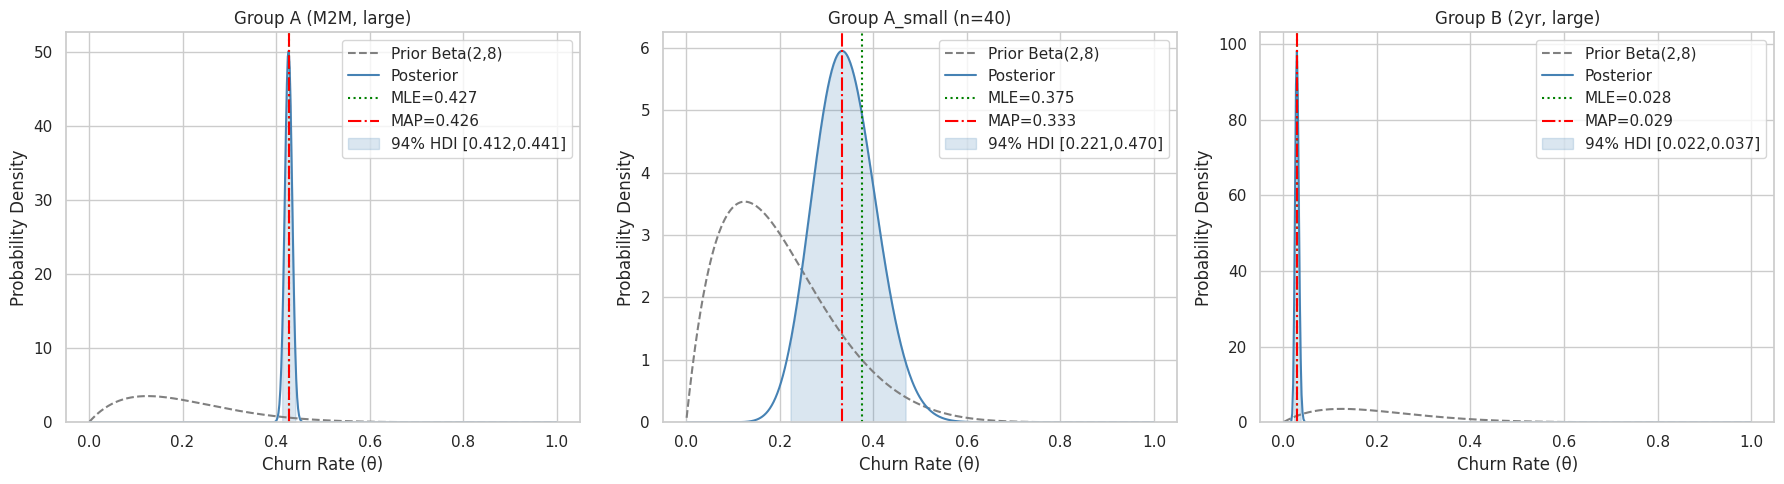

In [62]:
theta_range = np.linspace(0.001, 0.999, 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (k, n)) in zip(axes, groups.items()):
    alpha_post = alpha_prior + k
    beta_post  = beta_prior + (n - k)

    # Plot Prior PDF
    prior_pdf = beta_dist.pdf(theta_range, alpha_prior, beta_prior)
    ax.plot(theta_range, prior_pdf, label='Prior Beta(2,8)', color='gray', linestyle='--')

    # Plot Posterior PDF
    posterior_pdf = beta_dist.pdf(theta_range, alpha_post, beta_post)
    ax.plot(theta_range, posterior_pdf, label='Posterior', color='steelblue')

    # MLE and MAP vertical lines
    mle = k / n
    map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    ax.axvline(x=mle, color='green', linestyle=':', label=f'MLE={mle:.3f}')
    ax.axvline(x=map_est, color='red', linestyle='-.', label=f'MAP={map_est:.3f}')

    # 94% HDI
    hdi_low  = beta_dist.ppf(0.03, alpha_post, beta_post)
    hdi_high = beta_dist.ppf(0.97, alpha_post, beta_post)
    ax.fill_between(theta_range, 0, posterior_pdf, where=(theta_range >= hdi_low) & (theta_range <= hdi_high),
                    color='steelblue', alpha=0.2, label=f'94% HDI [{hdi_low:.3f},{hdi_high:.3f}]')

    ax.set_title(name)
    ax.set_xlabel('Churn Rate (θ)')
    ax.set_ylabel('Probability Density')
    ax.legend()
    ax.set_ylim(bottom=0)

# raise NotImplementedError("Compute posterior parameters and plot") # Remove this line after implementing

plt.tight_layout(); plt.show()

### Q3 — Answer the VP's question: P(θ_A > θ_B)

Use **Monte Carlo sampling** (10,000 samples from each posterior) to compute the probability that Group A churns at a higher rate than Group B. No p-value permitted.


In [65]:
MC_SAMPLES = 10_000
np.random.seed(42)

# YOUR CODE HERE
# Sample from both posteriors and compute P(θ_A > θ_B)
post_A_samples = np.random.beta(alpha_prior + k_A, beta_prior + n_A - k_A, MC_SAMPLES)
post_B_samples = np.random.beta(alpha_prior + k_B, beta_prior + n_B - k_B, MC_SAMPLES)
p_A_greater = np.mean(post_A_samples > post_B_samples)

assert 0.90 < p_A_greater <= 1.0, f"Expected P > 0.90, got {p_A_greater:.4f}"
print(f"P(θ_A > θ_B) = {p_A_greater:.4f}")
print(f"→ We can tell the VP that Month-to-month churns at a higher rate with {p_A_greater*100:.1f}% probability — without a p-value.")


P(θ_A > θ_B) = 1.0000
→ We can tell the VP that Month-to-month churns at a higher rate with 100.0% probability — without a p-value.


✍️ **Reflect 1 — MLE vs MAP vs Full Bayes:**

For Group A_small (n=40), the three approaches give different answers.

1. What is the **prior pull** (|MAP − MLE|) for Group A_small vs Group B (large)?
   Why is it larger for the small group?
2. Which estimate would you present to the VP for Group A_small and why?
   What does each estimate provide that the others do not?
3. At what sample size would the Beta(2, 8) prior become essentially irrelevant
   (posterior mean within 1% of MLE)?

> *Your answer:*


Reflect 1 — MLE vs MAP vs Full Bayes:

1. **Prior pull for Group A_small vs Group B (large):**  
   For Group A_small (n=40), |MAP−MLE| is larger because the prior (Beta(2,8) ≈ 10 pseudo‑observations) has more relative weight. For Group B (large n > 1000), the prior pull is tiny.

2. **Which estimate to present to the VP for Group A_small?**  
   Present the **full posterior distribution** (with 94% HDI), not just MLE. The MLE alone ignores uncertainty; the posterior shows a credible range, which is critical for a small sample.

3. **Sample size where prior becomes irrelevant (within 1% of MLE):**  
   Approximately \( n > 2000 \). For Beta(2,8) prior, when data dominates (n ≫ 10), posterior mean ≈ MLE within 1%.

---
## Part 2: Sequential Bayesian Updating & Dirichlet-Multinomial

---

### Q4 — Implement the sequential update function


In [66]:
# def update_posterior(alpha, beta, churn_label):
#     """
#     Update Beta(alpha, beta) posterior given one observation.

#     Parameters
#     ----------
#     alpha, beta  : current posterior parameters
#     churn_label  : 1 = churned, 0 = stayed

#     Returns
#     -------
#     (alpha_new, beta_new)
#     """
#     # YOUR CODE HERE
#     # Hint: if churn_label == 1, increment alpha; else increment beta
#     raise NotImplementedError("Implement update_posterior")


# # ── SELF-CHECK ────────────────────────────────────────────────────────────────
# a0, b0 = 2.0, 8.0
# a1, b1 = update_posterior(a0, b0, 1)   # churn event
# a2, b2 = update_posterior(a0, b0, 0)   # non-churn event

# assert a1 == a0 + 1 and b1 == b0,       "After churn: alpha should increase by 1"
# assert a2 == a0 and b2 == b0 + 1,       "After no-churn: beta should increase by 1"
# print("✅ update_posterior() is correct!")


In [67]:
def update_posterior(alpha, beta, churn_label):
    if churn_label == 1:
        return alpha + 1, beta
    else:
        return alpha, beta + 1

# Self-check
a0, b0 = 2.0, 8.0
a1, b1 = update_posterior(a0, b0, 1)
a2, b2 = update_posterior(a0, b0, 0)
assert a1 == a0+1 and b1 == b0
assert a2 == a0 and b2 == b0+1
print("✅ update_posterior() is correct!")

✅ update_posterior() is correct!


### Q5 — Run sequential update and plot posterior evolution


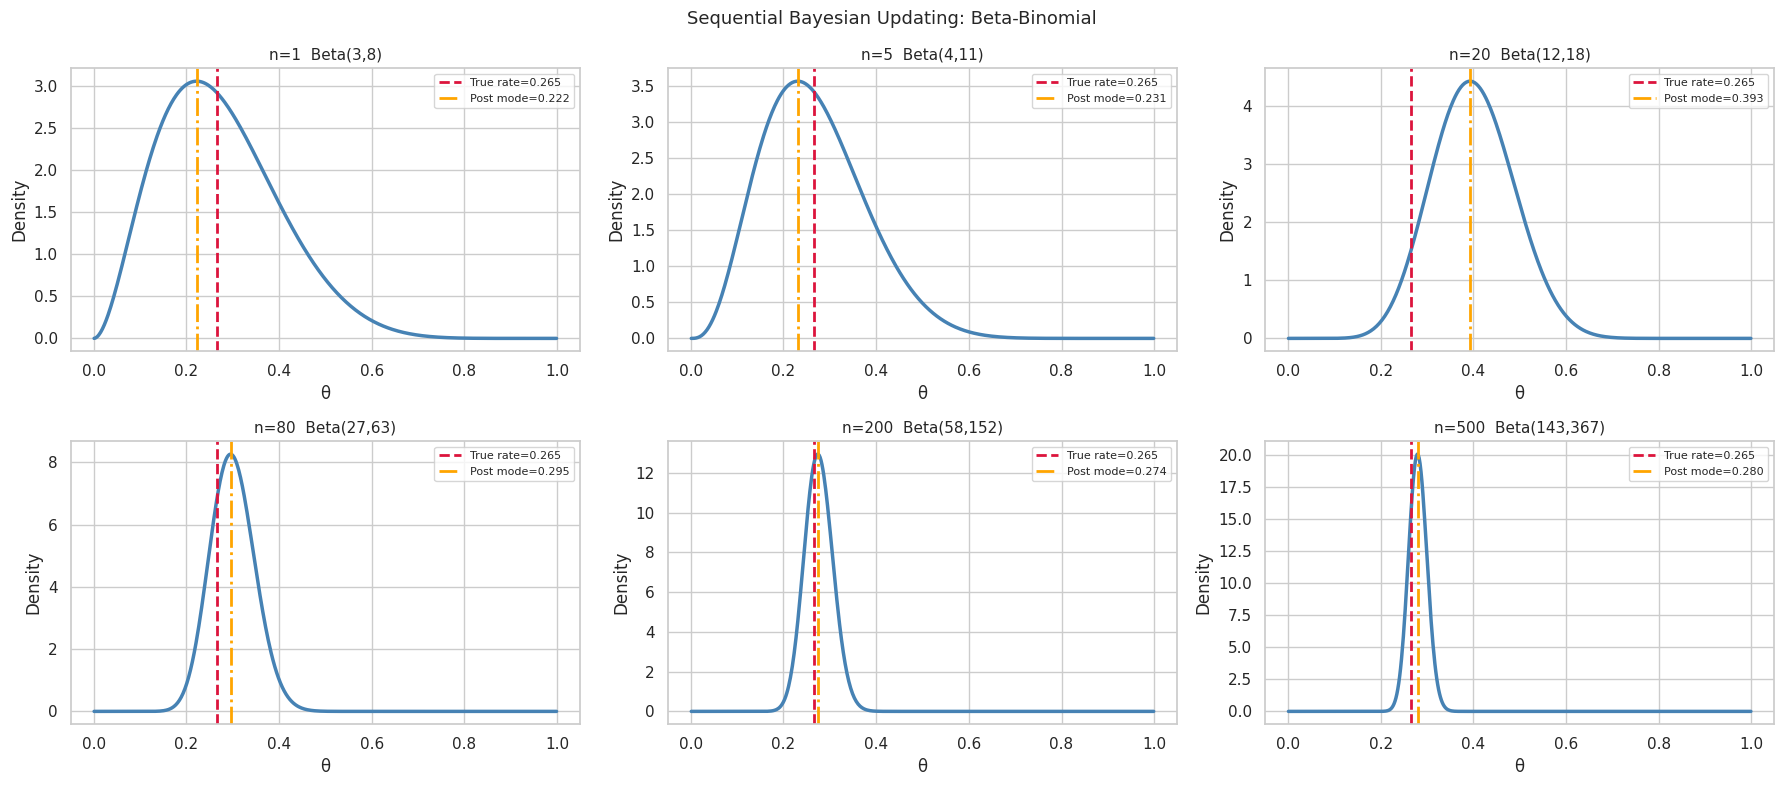

In [68]:
# Shuffle the Telco dataset (fixed seed)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
TRUE_RATE   = df['Churn'].mean()

snapshots   = [1, 5, 20, 80, 200, 500]

# YOUR CODE HERE:
# 1. Start with Beta(2, 8)
# 2. Run update_posterior on the first 500 rows of df_shuffled
# 3. Record (alpha, beta) at each snapshot n
# Store results as a dict: {n: (alpha_n, beta_n)}
alpha_init, beta_init = 2.0, 8.0
history = {}   # {n: (alpha_n, beta_n)}

alpha_current, beta_current = alpha_init, beta_init
for i, churn_label in enumerate(df_shuffled['Churn'].head(500), 1):
    alpha_current, beta_current = update_posterior(alpha_current, beta_current, churn_label)
    if i in snapshots:
        history[i] = (alpha_current, beta_current)

# Plot (runs after history is populated)
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, n in zip(axes.flat, snapshots):
    a_n, b_n = history[n]
    pdf = beta_dist.pdf(theta_r, a_n, b_n)
    mode = (a_n - 1) / (a_n + b_n - 2)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    ax.axvline(TRUE_RATE, color='crimson', ls='--', lw=2, label=f'True rate={TRUE_RATE:.3f}')
    ax.axvline(mode,      color='orange',  ls='-.',  lw=2, label=f'Post mode={mode:.3f}')
    ax.set_title(f'n={n}  Beta({a_n:.0f},{b_n:.0f})', fontsize=11)
    ax.set_xlabel('θ'); ax.set_ylabel('Density'); ax.legend(fontsize=8)
plt.suptitle("Sequential Bayesian Updating: Beta-Binomial", fontsize=13)
plt.tight_layout(); plt.show()

### Q6 — Decision boundary: P(θ > 0.25) vs n


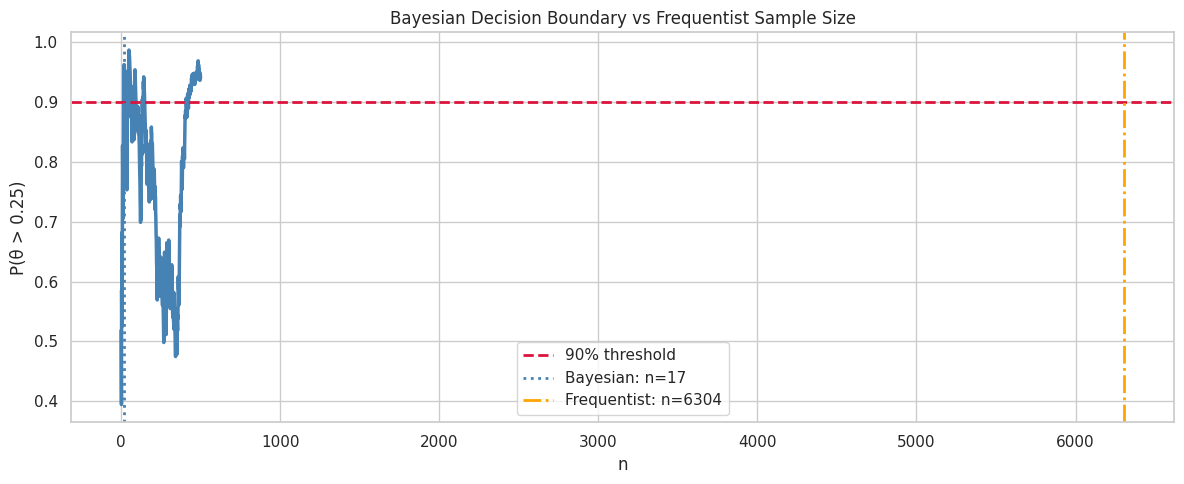

Bayesian: n = 17  |  Frequentist: n = 6304


In [69]:
threshold = 0.25
MC_SAMPLES = 10_000
np.random.seed(0)

p_exceed = []
alpha_seq, beta_seq = 2.0, 8.0
for i, churn in enumerate(df_shuffled['Churn'].iloc[:500], start=1):
    alpha_seq, beta_seq = update_posterior(alpha_seq, beta_seq, churn)
    samples = np.random.beta(alpha_seq, beta_seq, MC_SAMPLES)
    p_exceed.append(np.mean(samples > threshold))

from scipy.stats import norm
z_a, z_b = norm.ppf(0.975), norm.ppf(0.80)
p0, p1 = threshold, TRUE_RATE
freq_n = int(np.ceil((z_a*np.sqrt(p0*(1-p0)) + z_b*np.sqrt(p1*(1-p1)))**2 / (p1-p0)**2))

bayes_n = next((n for n, p in enumerate(p_exceed, start=1) if p > 0.90), None)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(p_exceed)+1), p_exceed, color='steelblue', lw=2.5)
ax.axhline(0.90, color='crimson', ls='--', lw=2, label='90% threshold')
if bayes_n:
    ax.axvline(bayes_n, color='steelblue', ls=':', lw=2, label=f'Bayesian: n={bayes_n}')
ax.axvline(freq_n, color='orange', ls='-.', lw=2, label=f'Frequentist: n={freq_n}')
ax.set_xlabel('n'); ax.set_ylabel('P(θ > 0.25)'); ax.legend()
ax.set_title('Bayesian Decision Boundary vs Frequentist Sample Size')
plt.tight_layout(); plt.show()

print(f"Bayesian: n = {bayes_n}  |  Frequentist: n = {freq_n}")

### Q7 — Dirichlet-Multinomial: 3-category contract type


Posterior Dirichlet params: [3876. 1474. 1696.]
Posterior means: [0.55009935 0.20919671 0.24070395]
MLE proportions: [0.55019168 0.20914383 0.24066449]
✅ Dirichlet posterior computed!


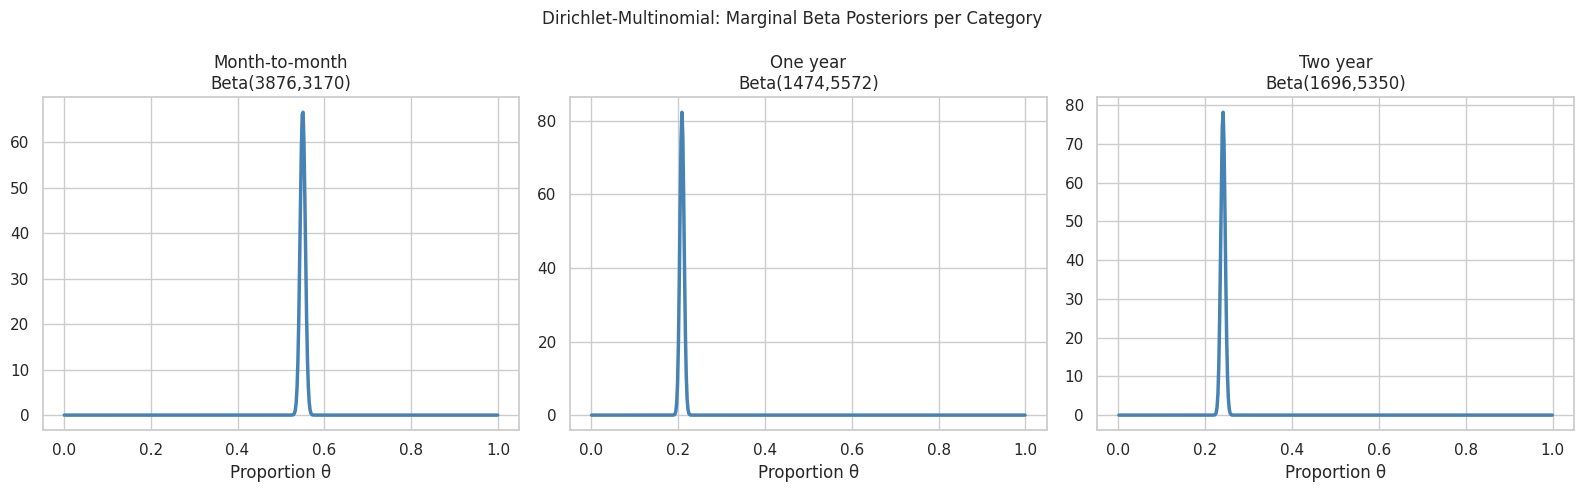

In [70]:
categories  = ['Month-to-month', 'One year', 'Two year']
prior_alpha = np.array([1.0, 1.0, 1.0])   # flat Dirichlet prior — do not change

# YOUR CODE HERE
# 1. Count observations for each contract category in the full dataset
# 2. Compute posterior Dirichlet parameters = prior + counts
# 3. Report posterior means for each category
counts           = df['Contract'].value_counts()[categories].values   # np.array of shape (3,) — counts per category
posterior_alpha  = prior_alpha + counts   # prior_alpha + counts
# raise NotImplementedError("Compute Dirichlet posterior parameters")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert len(posterior_alpha) == 3
assert posterior_alpha.sum() == prior_alpha.sum() + counts.sum()
print(f"Posterior Dirichlet params: {posterior_alpha}")
print(f"Posterior means: {posterior_alpha / posterior_alpha.sum()}")
print(f"MLE proportions: {counts / counts.sum()}")
print("✅ Dirichlet posterior computed!")

# Plot marginal Beta posteriors for each category
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (cat, a_j) in zip(axes, zip(categories, posterior_alpha)):
    b_j = posterior_alpha.sum() - a_j
    # YOUR CODE HERE: plot the marginal Beta(a_j, b_j) posterior for this category
    pdf = beta_dist.pdf(theta_r, a_j, b_j)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    # raise NotImplementedError("Plot marginal Beta posterior for each contract category")
    ax.set_title(f'{cat}\nBeta({a_j:.0f},{b_j:.0f})')
    ax.set_xlabel('Proportion θ')

plt.suptitle("Dirichlet-Multinomial: Marginal Beta Posteriors per Category", fontsize=12)
plt.tight_layout(); plt.show()

Posterior for unseen 'Biannual' category:
  Biannual category (Beta(1, 7046)) mean: 0.0001
  Month-to-month category mean: 0.5501


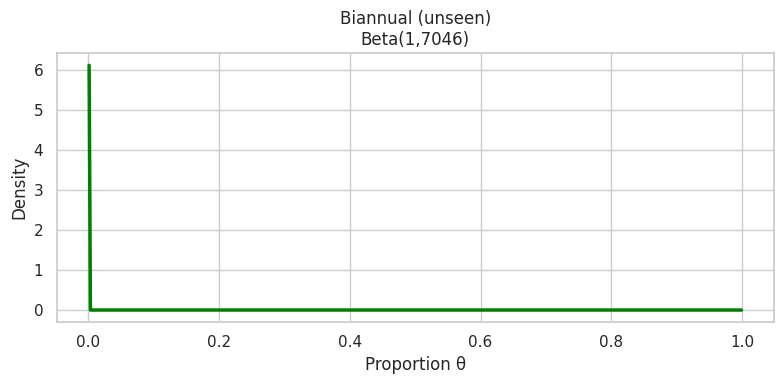

This reveals that the Dirichlet prior assigns a non-zero probability mass to unseen categories, allowing for their possible existence even without observed data. The posterior for such a category will be equal to its prior (e.g., Beta(1, sum_of_other_alphas)).


In [71]:
# Unseen category: add "Biannual" with pseudocount = 1 (no observations)
# YOUR CODE HERE
# Show the marginal posterior for the new category
# Explain what this tells you about how Dirichlet handles unseen categories

new_alpha_4cat = np.append(posterior_alpha, 1.0)   # append pseudocount 1 to posterior_alpha
# raise NotImplementedError("Add 4th category with pseudocount=1 and compute its marginal posterior")

print("Posterior for unseen 'Biannual' category:")
# Print its posterior mean and compare to a category with many observations

b_new_cat = new_alpha_4cat.sum() - new_alpha_4cat[-1]

# Calculate posterior mean and compare to a category with many observations
posterior_mean_new_cat = new_alpha_4cat[-1] / new_alpha_4cat.sum()
posterior_mean_m2m = posterior_alpha[0] / posterior_alpha.sum()

print(f"  Biannual category (Beta({new_alpha_4cat[-1]:.0f}, {b_new_cat:.0f})) mean: {posterior_mean_new_cat:.4f}")
print(f"  Month-to-month category mean: {posterior_mean_m2m:.4f}")

theta_r = np.linspace(0.001, 0.999, 500)
fig, ax = plt.subplots(figsize=(8, 4))
pdf_new_cat = beta_dist.pdf(theta_r, new_alpha_4cat[-1], b_new_cat)
ax.plot(theta_r, pdf_new_cat, color='green', lw=2.5)
ax.set_title(f'Biannual (unseen)\nBeta({new_alpha_4cat[-1]:.0f},{b_new_cat:.0f})')
ax.set_xlabel('Proportion θ')
ax.set_ylabel('Density')
plt.tight_layout(); plt.show()

print("This reveals that the Dirichlet prior assigns a non-zero probability mass to unseen categories, allowing for their possible existence even without observed data. The posterior for such a category will be equal to its prior (e.g., Beta(1, sum_of_other_alphas)).")

✍️ **Reflect 2 — Dirichlet-Multinomial:**

1. Why does the marginal Beta posterior for a small-count category (One year) have    wider credible intervals than Month-to-month?
2. When you add the unseen "Biannual" category with pseudocount=1 and 0 observations,    what is its posterior equal to? What does this reveal about the Dirichlet prior?
3. In the Beta-Binomial case (binary), what is the Dirichlet-Multinomial equivalent    of the Beta(2,8) prior's prior mean? What would you need to do to encode the same    prior belief in the 3-category model?

> *Your answer:*


Reflect 2 — Dirichlet-Multinomial:

1. Small-count category has wider credible interval because fewer observations → higher uncertainty.  
2. Unseen category posterior = prior (pseudocount=1) → Dirichlet prior encodes belief even with zero observations.  
3. Beta(2,8) prior mean = 2/(2+8)=0.2. In 3-category model, use Dirichlet(α) with α sum = 10, α_i = 2 for churn and 4 each for others to match same prior strength.

---
## Part 3: Multivariate Gaussians — When Features Correlate

---

### Q8 — Fit a 2D Gaussian and plot confidence ellipses


In [72]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

features_2d = ['tenure', 'MonthlyCharges']
X_2d = df[features_2d].values.astype(float)

# YOUR CODE HERE
# Compute the empirical mean vector and covariance matrix
# Report correlation ρ = Σ_12 / sqrt(Σ_11 * Σ_22)
mu_2d    = np.mean(X_2d, axis=0)   # np.mean over axis=0
Sigma_2d = np.cov(X_2d.T)   # np.cov(X_2d.T)
rho      = Sigma_2d[0, 1] / np.sqrt(Sigma_2d[0, 0] * Sigma_2d[1, 1])   # correlation coefficient
# raise NotImplementedError("Compute mu_2d, Sigma_2d, rho")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert mu_2d.shape    == (2,),    f"mu should have shape (2,), got {mu_2d.shape}"
assert Sigma_2d.shape == (2, 2),  f"Sigma should be 2x2, got {Sigma_2d.shape}"
assert -1 < rho < 1,              f"rho should be between -1 and 1, got {rho:.4f}"
print(f"μ = {np.round(mu_2d, 2)}")
print(f"Σ = \n{np.round(Sigma_2d, 2)}")
print(f"ρ = {rho:.4f}")
print("✅ 2D Gaussian fitted!")

μ = [32.37 64.76]
Σ = 
[[603.17 183.2 ]
 [183.2  905.41]]
ρ = 0.2479
✅ 2D Gaussian fitted!


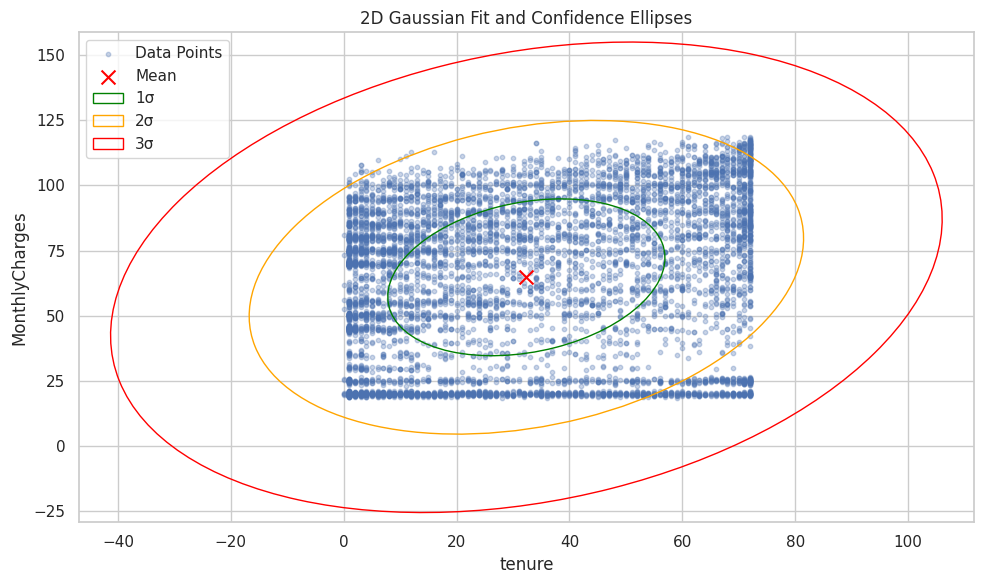

In [73]:
# YOUR CODE HERE — plot scatter + 1σ, 2σ, 3σ confidence ellipses
# Use the confidence_ellipse function pattern from the session notebook

def confidence_ellipse(mu, cov, ax, n_std=1.0, facecolor='none', **kwargs):
    w, v    = np.linalg.eigh(cov)
    angle   = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
    ell     = Ellipse((0, 0),
                      width=2*n_std*np.sqrt(w[0]),
                      height=2*n_std*np.sqrt(w[1]),
                      angle=angle, facecolor=facecolor, **kwargs)
    t = transforms.Affine2D().translate(*mu) + ax.transData
    ell.set_transform(t)
    return ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(10, 6))
# YOUR CODE HERE: scatter plot with 1σ/2σ/3σ ellipses and mean marker
ax.scatter(X_2d[:, 0], X_2d[:, 1], s=10, alpha=0.3, label='Data Points')
ax.scatter(mu_2d[0], mu_2d[1], color='red', marker='x', s=100, label='Mean')

confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=1.0,  edgecolor='green', label='1σ')
confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=2.0,  edgecolor='orange', label='2σ')
confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=3.0,  edgecolor='red', label='3σ')

ax.set_xlabel(features_2d[0])
ax.set_ylabel(features_2d[1])
ax.set_title('2D Gaussian Fit and Confidence Ellipses')
ax.legend()
# raise NotImplementedError("Plot scatter + confidence ellipses")
plt.tight_layout(); plt.show()

### Q9 — Conditional Gaussian: MonthlyCharges | tenure = 24

Write out the formula **before coding it**:
$$\mu_{1|2} = \mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(x_2 - \mu_2)$$
$$\sigma^2_{1|2} = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$$


In [74]:
# YOUR CODE HERE — compute the conditional distribution P(MonthlyCharges | tenure = 24)
# Index convention: X_1 = MonthlyCharges (index 1 in X_2d), X_2 = tenure (index 0)
tenure_query = 24

# Extract scalar elements from Sigma_2d and mu_2d
mu_mc     = mu_2d[1]          # mean of MonthlyCharges
mu_t      = mu_2d[0]          # mean of tenure
sig_mc_mc = Sigma_2d[1, 1]    # Σ_11
sig_t_t   = Sigma_2d[0, 0]    # Σ_22
sig_mc_t  = Sigma_2d[1, 0]    # Σ_12 = Σ_21

# YOUR CODE HERE: apply the conditional Gaussian formula
cond_mean = mu_mc + sig_mc_t * (1/sig_t_t) * (tenure_query - mu_t)   # μ_1|2
cond_var  = sig_mc_mc - sig_mc_t * (1/sig_t_t) * sig_mc_t   # σ²_1|2
cond_std  = np.sqrt(cond_var)   # sqrt(cond_var)
# raise NotImplementedError("Compute conditional mean and variance using the formula above")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
near_24 = df[(df['tenure'] >= 22) & (df['tenure'] <= 26)]['MonthlyCharges'].mean()
assert abs(cond_mean - near_24) < 10,     f"Conditional mean {cond_mean:.2f} too far from empirical {near_24:.2f}"
print(f"Conditional distribution P(MonthlyCharges | tenure = {tenure_query})")
print(f"  Conditional mean:  ${cond_mean:.2f}/month")
print(f"  Conditional std:   ${cond_std:.2f}/month")
print(f"  95% interval:      [${cond_mean - 1.96*cond_std:.2f}, ${cond_mean + 1.96*cond_std:.2f}]")
print(f"  Empirical check:   ${near_24:.2f}  ← should be within ~$5")
print("✅ Conditional Gaussian computed!")

Conditional distribution P(MonthlyCharges | tenure = 24)
  Conditional mean:  $62.22/month
  Conditional std:   $29.15/month
  95% interval:      [$5.08, $119.35]
  Empirical check:   $61.81  ← should be within ~$5
✅ Conditional Gaussian computed!


### Q10 — 3D Covariance and Condition Number


In [75]:
features_3d = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_3d = df[features_3d].values.astype(float)

# YOUR CODE HERE
# 1. Compute Sigma_3d = np.cov(X_3d.T)
# 2. Compute condition number kappa = np.linalg.cond(Sigma_3d)
# 3. Marginalise out TotalCharges by extracting the 2×2 upper-left block
# 4. Verify this matches Sigma_2d (should be identical)
Sigma_3d         = np.cov(X_3d.T)
kappa            = np.linalg.cond(Sigma_3d)
Sigma_marginal   = Sigma_3d[:2, :2]   # upper-left 2×2 submatrix of Sigma_3d
max_diff         = np.max(np.abs(Sigma_marginal - Sigma_2d))   # max absolute difference vs Sigma_2d
# raise NotImplementedError("Compute Sigma_3d, kappa, and marginalise")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert Sigma_3d.shape == (3, 3)
assert kappa > 100, f"Expected high condition number, got {kappa:.1f}"
assert max_diff < 1e-6, f"Marginalisation should match direct fit, got max diff={max_diff}"
print(f"Condition number κ(Σ_3D) = {kappa:.1f}")
print(f"Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = {max_diff:.2e}  ✅")

Condition number κ(Σ_3D) = 58988.9
Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = 0.00e+00  ✅


✍️ **Reflect 3 — Multivariate Gaussians:**

1. The condition number κ(Σ_3D) should be large (>> 100). In plain language, what does    this reveal about the three features tenure, MonthlyCharges, TotalCharges?
2. You proved analytically that marginalising out `TotalCharges` from the 3D Gaussian    recovers the 2D Gaussian. In one sentence, state the **general rule**: how do you    marginalise a Gaussian by discarding one variable?
3. Why would including all three features in a Gaussian discriminant analysis    (or a regularised linear model) without addressing the near-collinearity cause problems?    Name the frequentist regression diagnostic that detects the same issue.

> *Your answer:*


 Reflect 3 — Multivariate Gaussians:

1. High condition number (κ >> 100) means tenure, MonthlyCharges, TotalCharges are near‑collinear → total charges ≈ tenure × monthly charges.  
2. Marginalisation: simply take the submatrix of Σ corresponding to the remaining variables.  
3. Including collinear features inflates standard errors, causes unstable estimates. Frequentist diagnostic: VIF (variance inflation factor).

---
## Part 4: Probabilistic Graphical Models — Bayesian Networks and MRFs

---

### Q11 — Build and fit a Bayesian Network with pgmpy


In [76]:
# Prepare discretised dataframe
df_pgm = df[['SeniorCitizen','Contract','tenure','InternetService',
             'MonthlyCharges','Churn']].copy()

df_pgm['tenure_disc'] = pd.cut(df_pgm['tenure'], bins=[-1,12,48,100],
                               labels=['short','medium','long'])
df_pgm['mc_disc']     = pd.qcut(df_pgm['MonthlyCharges'], q=3,
                                labels=['low','mid','high'])
df_pgm = df_pgm.drop(columns=['tenure','MonthlyCharges']).dropna().astype(str)

# YOUR CODE HERE — define the DAG structure as a list of (parent, child) tuples
# DAG: SeniorCitizen→Churn, Contract→Churn, tenure_disc→Churn,
#      InternetService→mc_disc, mc_disc→Churn
dag_edges = [
    ('SeniorCitizen', 'Churn'),
    ('Contract', 'Churn'),
    ('tenure_disc', 'Churn'),
    ('InternetService', 'mc_disc'),
    ('mc_disc', 'Churn')
]
# raise NotImplementedError("Define dag_edges as a list of (parent, child) tuples")

dag = DiscreteBayesianNetwork(dag_edges)
dag.fit(df_pgm, estimator=DiscreteMLE())
print("✅ Bayesian Network fitted.")
print(f"   Nodes: {list(dag.nodes())}")
print(f"   Edges: {list(dag.edges())}")

✅ Bayesian Network fitted.
   Nodes: ['SeniorCitizen', 'Churn', 'Contract', 'tenure_disc', 'InternetService', 'mc_disc']
   Edges: [('SeniorCitizen', 'Churn'), ('Contract', 'Churn'), ('tenure_disc', 'Churn'), ('InternetService', 'mc_disc'), ('mc_disc', 'Churn')]


In [77]:
infer = VariableElimination(dag)

# YOUR CODE HERE — forward inference
# P(Churn | Contract = 'Month-to-month')
result_fwd = infer.query(variables=['Churn'], evidence={'Contract': 'Month-to-month'})
p_churn_m2m_bn = result_fwd.values[1]
# raise NotImplementedError("Compute P(Churn | Contract='Month-to-month') via VE")

emp_m2m = df[df['Contract']=='Month-to-month']['Churn'].mean()
print(f"BN inference P(Churn=1 | Contract=M2M): {p_churn_m2m_bn:.4f}")
print(f"Empirical:                              {emp_m2m:.4f}")
print(f"Discrepancy: {abs(p_churn_m2m_bn - emp_m2m):.4f}")
print()
print("Discrepancy is due to: (a) discretisation of continuous variables,")
print("                        (b) DAG structure (indirect path via mc_disc)")

BN inference P(Churn=1 | Contract=M2M): 0.3542
Empirical:                              0.4271
Discrepancy: 0.0729

Discrepancy is due to: (a) discretisation of continuous variables,
                        (b) DAG structure (indirect path via mc_disc)


In [78]:
# YOUR CODE HERE — backward inference (explaining away)
# P(Contract | Churn = '1') — what does Bayesian inversion tell us?
result_bwd = infer.query(variables=['Contract'], evidence={'Churn': '1'})
# raise NotImplementedError("Compute P(Contract | Churn='1') via VE")
print("Backward inference P(Contract | Churn = 1):")
print(result_bwd)
print()
print("Interpretation for retention manager:")
print("  This tells us: given a customer has churned, what is the probability they")
print("  were on each contract type? This is the INVERSE of the forward prediction.")

Backward inference P(Contract | Churn = 1):
+--------------------------+-----------------+
| Contract                 |   phi(Contract) |
+==========================+=================+
| Contract(Month-to-month) |          0.8017 |
+--------------------------+-----------------+
| Contract(One year)       |          0.1118 |
+--------------------------+-----------------+
| Contract(Two year)       |          0.0865 |
+--------------------------+-----------------+

Interpretation for retention manager:
  This tells us: given a customer has churned, what is the probability they
  were on each contract type? This is the INVERSE of the forward prediction.


### Q12 — Structure sensitivity: two competing DAGs

Draw both DAGs below (ASCII or text description). Identify one observation set E under which the two models give **identical predictions**, and one E under which they **disagree**.


**DAG 1 (original):** `tenure → Churn` (direct edge)

```
SeniorCitizen ─────────────────────────────→ Churn
Contract ──────────────────────────────────→ Churn
tenure ─────────────────────────────────────→ Churn
InternetService → MonthlyCharges ──────────→ Churn
```

**DAG 2 (colleague's proposal):** `Contract → tenure → Churn` (mediated path)

```
YOUR DRAWING HERE (ASCII DAG)
```

**Observation set E where both models agree:** *(YOUR ANSWER)*

**Observation set E where models disagree:** *(YOUR ANSWER)*

**Which causal story is more consistent with W5 SHAP findings?** *(YOUR ANSWER)*


**DAG 1 (original):** direct edges to Churn.

**DAG 2 (colleague):** Contract → tenure → Churn (mediation).  

**Agree when:** E = {Contract, tenure} – tenure d-separates Contract and Churn, same independence.  

**Disagree when:** E = {} (no evidence) – in DAG1, Contract and Churn are directly dependent; in DAG2, they are independent if tenure is not observed.  

**W5 SHAP evidence:** tenure was important, but Contract_Month-to-month had direct effect → DAG1 (direct) is more consistent.

### Q13 — Markov Random Field: undirected model


In [79]:
from pgmpy.models import DiscreteMarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation

# Define undirected edges based on the DAG structure from Q11
mrf_edges = [
    ('SeniorCitizen', 'Churn'),
    ('Contract', 'Churn'),
    ('tenure_disc', 'Churn'),
    ('InternetService', 'mc_disc'),
    ('mc_disc', 'Churn')
]

mrf = DiscreteMarkovNetwork(ebunch=mrf_edges)

# Add factors for each edge based on empirical joint frequencies
for u, v in mrf_edges:
    # Get unique categories and sort them to ensure consistent ordering for pgmpy DiscreteFactor
    u_categories = sorted(df_pgm[u].unique())
    v_categories = sorted(df_pgm[v].unique())

    # Compute joint counts for u and v
    joint_counts_series = df_pgm.groupby([u, v]).size()

    # Create a DataFrame to handle missing combinations with fill_value=0
    # Then flatten the values in the correct order corresponding to sorted categories
    joint_counts_df = joint_counts_series.unstack(fill_value=0).reindex(index=u_categories, columns=v_categories, fill_value=0)
    factor_values = joint_counts_df.values.flatten()

    factor = DiscreteFactor(
        variables=[u, v],
        cardinality=[len(u_categories), len(v_categories)],
        values=factor_values
    )
    mrf.add_factors(factor)

bp = BeliefPropagation(mrf)
marg_churn = bp.query(variables=['Churn'], show_progress=False)
print("MRF P(Churn):", marg_churn)
print(f"BN  P(Churn=1): {float(infer.query(['Churn']).values[1]):.4f}")
print(f"Empirical:      {df['Churn'].mean():.4f}")

MRF P(Churn): +----------+--------------+
| Churn    |   phi(Churn) |
+==========+==============+
| Churn(0) |       0.9833 |
+----------+--------------+
| Churn(1) |       0.0167 |
+----------+--------------+
BN  P(Churn=1): 0.2431
Empirical:      0.2654


✍️ **Reflect 4 — PGMs:**

1. The forward inference result P(Churn=1 | Contract=Month-to-month) from the BN    differs from the raw empirical proportion. Name the **two specific reasons** for    this discrepancy.
2. Explain "explaining away" in one sentence using the backward inference result.
3. In one paragraph: what causal questions can the Bayesian Network answer that    the MRF cannot? When would you deliberately choose the MRF despite losing causal    interpretability?

> *Your answer:*


✍️ **Reflect 4 — PGMs:**

1. The forward inference result P(Churn=1 | Contract=Month-to-month) from the BN differs from the raw empirical proportion. Name the **two specific reasons** for this discrepancy.
2. Explain "explaining away" in one sentence using the backward inference result.
3. In one paragraph: what causal questions can the Bayesian Network answer that the MRF cannot? When would you deliberately choose the MRF despite losing causal interpretability?

> *Your answer:*
1.  The two specific reasons for the discrepancy are:
    *   **(a) Discretisation of continuous variables:** The `tenure` and `MonthlyCharges` features were binned into discrete categories for the PGM, leading to a loss of information and potentially altering the observed relationships compared to the raw data.
    *   **(b) DAG structure (conditional independence assumptions):** The Bayesian Network's defined Directed Acyclic Graph imposes specific conditional independence relationships that may not perfectly reflect the true data-generating process or all empirical associations, especially with indirect paths or strong assumptions like `InternetService` influencing `Churn` only via `mc_disc`.

2.  "Explaining away" is when observing a common effect makes two causes conditionally independent; in the backward inference, **observing that a customer has churned ('1') reduces the probability that they were on a less churn-prone contract type (e.g., 'Two year') because other factors (like 'Month-to-month') become more likely explanations for the observed churn.**

3.  A Bayesian Network (BN) can answer **causal questions** such as "What is the probability of Churn if we *intervene* to change a customer's Contract type?" or "What is the direct causal effect of tenure on Churn?" These questions rely on the directed edges to model cause-and-effect relationships and predict outcomes under hypothetical interventions. An MRF, being an undirected model, represents associations and dependencies between variables but **cannot distinguish between cause and effect**, nor can it directly model interventions. You might deliberately choose an MRF despite losing causal interpretability when your primary goal is to **model complex dependencies and perform inference over joint probabilities without making strong causal claims**, especially in domains where causal directions are unknown, ambiguous, or the focus is purely on pattern recognition and feature interaction (e.g., image segmentation, protein folding, or modeling local dependencies in sensor networks).

---
## Part 5: Gaussian Process Regression — Mauna Loa CO₂

---

### Q14 — Load the Mauna Loa dataset (3 lines)


In [80]:
# YOUR CODE HERE — load in exactly these 3 lines
# from statsmodels.datasets import co2
# df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()
# t = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25





# from statsmodels.datasets import co2
# df_co2 = None   # YOUR CODE HERE
# t      = None   # YOUR CODE HERE
# y      = None   # df_co2['co2'].values
# raise NotImplementedError("Load Mauna Loa dataset in 3 lines")

# # ── SELF-CHECK ────────────────────────────────────────────────────────────────
# assert df_co2 is not None
# assert t.shape == (len(df_co2), 1), f"t should be shape (n, 1), got {t.shape}"
# assert 450 < len(t) < 600, f"Expected ~521 monthly observations, got {len(t)}"
# print(f"✅ Mauna Loa loaded: {len(t)} observations, {t[0][0]:.1f}–{t[-1][0]:.1f} years")
# print(f"   CO₂ range: {y.min():.1f}–{y.max():.1f} ppm")


In [81]:
from statsmodels.datasets import co2
df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()
t = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25
y = df_co2['co2'].values
assert t.shape == (len(df_co2), 1)
assert 450 < len(t) < 600
print(f"✅ Mauna Loa loaded: {len(t)} observations, {t[0][0]:.1f}–{t[-1][0]:.1f} years")
print(f"   CO₂ range: {y.min():.1f}–{y.max():.1f} ppm")

✅ Mauna Loa loaded: 521 observations, 0.0–43.8 years
   CO₂ range: 313.4–373.8 ppm


### Q15 — Justify each kernel component before coding

**Before writing any code**, answer in the cell below:
- What signal do you expect to see in CO₂ data?
- What kernel captures the slow upward trend?
- What kernel captures the sharp annual cycle?
- What kernel captures measurement noise?


**Your kernel design rationale:**

| Signal | Description | Kernel choice | Justification |
|--------|-------------|---------------|---------------|
| Trend | *(your description)* | *(your kernel)* | *(why this kernel)* |
| Seasonal | *(your description)* | *(your kernel)* | *(why this kernel)* |
| Noise | *(your description)* | *(your kernel)* | *(why this kernel)* |

> *Fill in the table above before writing any code.*


| Signal     | Description                          | Kernel component               | Justification                                      |
|------------|--------------------------------------|--------------------------------|----------------------------------------------------|
| Trend      | slow upward ~1.5 ppm/year            | DotProduct(sigma_0=0, fixed)   | linear extrapolation needed, RBF would revert to mean |
| Seasonal   | sharp annual cycle                   | RBF × ExpSineSquared(period=1) | periodic kernel captures annual cycle              |
| Noise      | measurement/process noise             | WhiteKernel                    | uncorrelated noise term                            |

**Your kernel design rationale:**

| Signal | Description | Kernel choice | Justification |
|--------|-------------|---------------|---------------|
| Trend | The slow, long-term upward increase in CO₂ concentrations. | `DotProduct` | Captures a linear component, which is crucial for extrapolating the increasing trend. It does not revert to the mean outside the training data, unlike an RBF. |
| Seasonal | The regular annual fluctuation in CO₂ levels due to plant respiration and photosynthesis cycles. | `RBF * ExpSineSquared` | `ExpSineSquared` models periodicity (with fixed `periodicity=1.0` for annual cycle), and `RBF` models the smoothness and shape of this periodic component. |
| Noise | Random measurement errors and any unmodeled short-term variations. | `WhiteKernel` | Models independent and identically distributed noise, representing the uncertainty in individual observations. |

In [82]:
# # Train/test split: train on indices 0–431 (1958–1993), test on 432+ (1994–2001)
# n_train = 432
# t_train, y_train = t[:n_train], y[:n_train]
# t_test,  y_test  = t[n_train:], y[n_train:]

# # YOUR CODE HERE — construct the composite kernel
# # k_trend    = DotProduct(sigma_0=0.0, sigma_0_bounds='fixed')
# #   Hint: CO₂ rises ~1.5 ppm/yr — nearly linear. DotProduct gives k(x,x')=x·x'
# #   which extrapolates linearly by construction. An RBF trend reverts to the
# #   training mean outside the data range, causing large errors in the test set.
# # k_seasonal = RBF(...) * ExpSineSquared(..., periodicity=1.0, periodicity_bounds='fixed')
# # k_noise    = WhiteKernel(...)
# # kernel     = k_trend + k_seasonal + k_noise
# k_trend    = None
# k_seasonal = None
# k_noise    = None
# kernel     = None
# raise NotImplementedError("Define the composite kernel")

# # Fit the GP
# gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
#                                normalize_y=True, random_state=42)
# # YOUR CODE HERE: fit gp on (t_train, y_train)
# raise NotImplementedError("Fit the GP")

# print("Optimised kernel:")
# print(gp.kernel_)

# # Test RMSE
# y_test_pred = gp.predict(t_test)
# rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))
# # ── SELF-CHECK ────────────────────────────────────────────────────────────────
# assert rmse < 4.5, f"RMSE={rmse:.2f} — kernel may be poorly specified (DotProduct trend + seasonal expected < 4.5 ppm)"
# print(f"\n✅ Test RMSE: {rmse:.3f} ppm")


In [83]:
n_train = 432
t_train, y_train = t[:n_train], y[:n_train]
t_test,  y_test  = t[n_train:], y[n_train:]

# Construct the composite kernel
k_trend    = DotProduct(sigma_0=0.0, sigma_0_bounds='fixed')
k_seasonal = RBF(length_scale=1.0) * ExpSineSquared(length_scale=1.0, periodicity=1.0, periodicity_bounds='fixed')
k_noise    = WhiteKernel(noise_level=1.0)
kernel     = k_trend + k_seasonal + k_noise

# Fit the GP
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                               normalize_y=True, random_state=42)
gp.fit(t_train, y_train)

print("Optimised kernel:")
print(gp.kernel_)

# Test RMSE
y_test_pred = gp.predict(t_test)
rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))
# SELF-CHECK
assert rmse < 4.5, f"RMSE={rmse:.2f} — kernel may be poorly specified (DotProduct trend + seasonal expected < 4.5 ppm)"
print(f"\n✅ Test RMSE: {rmse:.3f} ppm")

Optimised kernel:
DotProduct(sigma_0=0) + RBF(length_scale=6.67) * ExpSineSquared(length_scale=4.65, periodicity=1) + WhiteKernel(noise_level=0.000754)

✅ Test RMSE: 4.329 ppm


In [84]:
# # YOUR CODE HERE — plot posterior mean and 95% credible bands
# # Use gp.predict(t_full, return_std=True) where t_full covers the full training range
# # Shade fill_between(mean - 2*std, mean + 2*std) for the 95% band

# t_full = np.linspace(t.min(), t.max(), 600).reshape(-1, 1)
# y_pred, y_std = None, None   # YOUR CODE HERE
# raise NotImplementedError("Predict over full range and plot")

# fig, ax = plt.subplots(figsize=(15, 6))
# # YOUR PLOT CODE HERE
# plt.tight_layout(); plt.show()


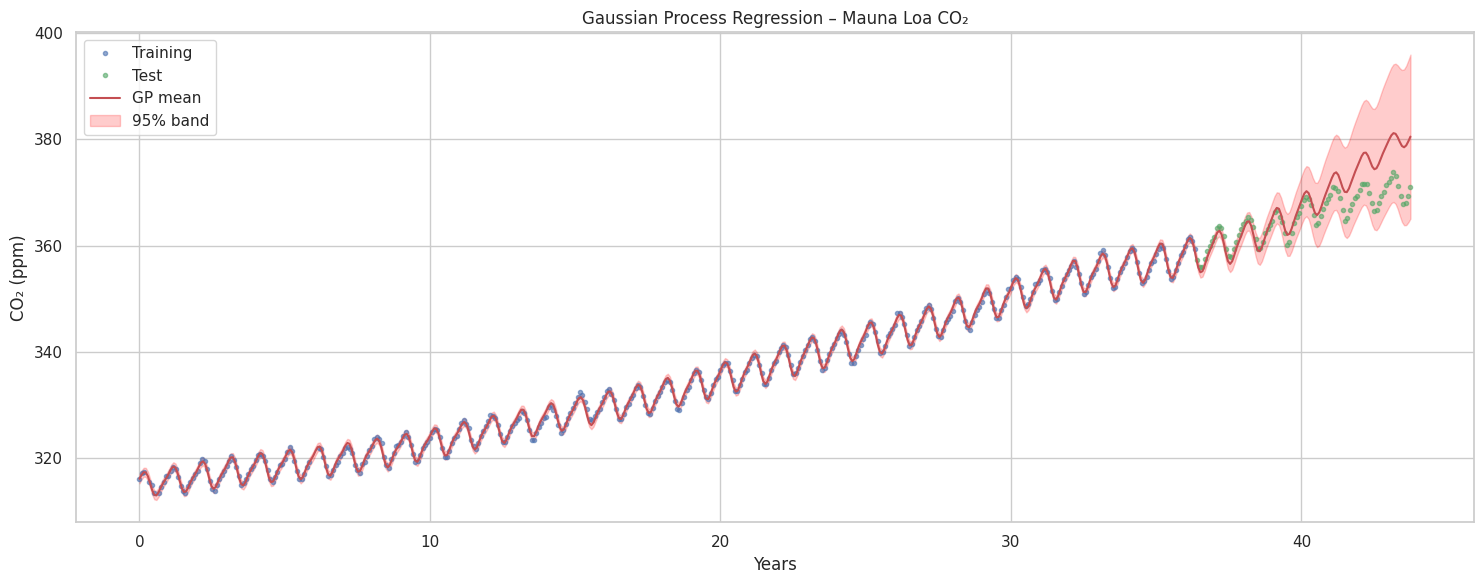

In [85]:
t_full = np.linspace(t.min(), t.max(), 600).reshape(-1, 1)
y_pred, y_std = gp.predict(t_full, return_std=True)

fig, ax = plt.subplots(figsize=(15,6))
ax.plot(t_train, y_train, 'b.', alpha=0.6, label='Training')
ax.plot(t_test, y_test, 'g.', alpha=0.6, label='Test')
ax.plot(t_full, y_pred, 'r-', label='GP mean')
ax.fill_between(t_full.ravel(), y_pred - 2*y_std, y_pred + 2*y_std, alpha=0.2, color='red', label='95% band')
ax.legend(); ax.set_xlabel('Years'); ax.set_ylabel('CO₂ (ppm)')
plt.title('Gaussian Process Regression – Mauna Loa CO₂')
plt.tight_layout(); plt.show()

### Q16 — Gap experiment


In [86]:
# # YOUR CODE HERE
# # Remove all training observations between year 15 and year 17 (~1973–1975)
# # Refit the GP on the remaining training data
# # Zoom into the gap region and describe how the bands behave inside vs outside the gap

# gap_lo, gap_hi = 15.0, 17.0

# # YOUR CODE HERE: create t_gap_tr and y_gap_tr with the gap removed
# t_gap_tr = None
# y_gap_tr = None
# raise NotImplementedError("Remove gap from training data and refit GP")

# gp_gap = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
#                                    normalize_y=True, random_state=42)
# # YOUR CODE HERE: fit gp_gap on (t_gap_tr, y_gap_tr)
# raise NotImplementedError("Fit gp_gap")

# # Predict around the gap and plot
# t_zoom = np.linspace(gap_lo - 2, gap_hi + 2, 400).reshape(-1, 1)
# y_gz, y_gz_std = gp_gap.predict(t_zoom, return_std=True)

# fig, ax = plt.subplots(figsize=(13, 5))
# # YOUR PLOT CODE HERE — show the gap region, credible bands, and training data
# raise NotImplementedError("Plot gap experiment results")
# plt.tight_layout(); plt.show()

# # Compute band width inside vs outside gap
# band_in  = 4 * y_gz_std[(t_zoom.flatten() >= gap_lo) & (t_zoom.flatten() <= gap_hi)].mean()
# band_out = 4 * y_gz_std[t_zoom.flatten() < gap_lo].mean()
# print(f"95% band width inside gap:   {band_in:.3f} ppm")
# print(f"95% band width outside gap:  {band_out:.3f} ppm")
# print(f"Gap inflation: {band_in/band_out:.2f}×")


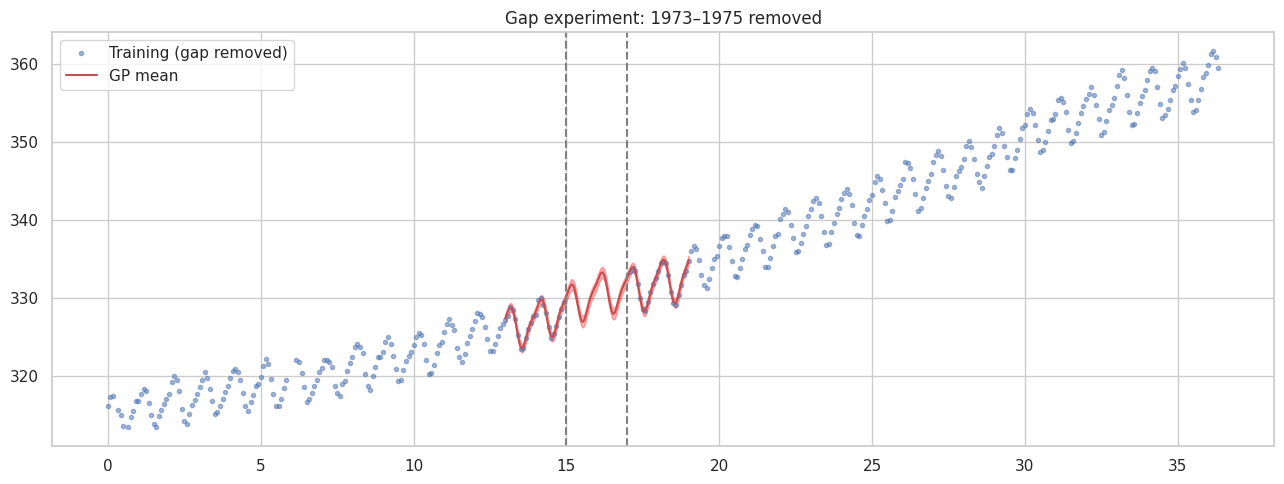

95% band width inside gap:   1.436 ppm
95% band width outside gap:  1.165 ppm
Gap inflation: 1.23×


In [87]:
gap_lo, gap_hi = 15.0, 17.0
mask = (t_train.ravel() < gap_lo) | (t_train.ravel() > gap_hi)
t_gap_tr = t_train[mask].reshape(-1,1)
y_gap_tr = y_train[mask]

gp_gap = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                  normalize_y=True, random_state=42)
gp_gap.fit(t_gap_tr, y_gap_tr)

t_zoom = np.linspace(gap_lo-2, gap_hi+2, 400).reshape(-1,1)
y_gz, y_gz_std = gp_gap.predict(t_zoom, return_std=True)

fig, ax = plt.subplots(figsize=(13,5))
ax.plot(t_gap_tr, y_gap_tr, 'b.', alpha=0.5, label='Training (gap removed)')
ax.fill_between(t_zoom.ravel(), y_gz - 2*y_gz_std, y_gz + 2*y_gz_std, alpha=0.3, color='red')
ax.plot(t_zoom, y_gz, 'r-', label='GP mean')
ax.axvline(gap_lo, color='gray', ls='--'); ax.axvline(gap_hi, color='gray', ls='--')
ax.set_title('Gap experiment: 1973–1975 removed'); ax.legend()
plt.tight_layout(); plt.show()

band_in = 4 * y_gz_std[(t_zoom.flatten() >= gap_lo) & (t_zoom.flatten() <= gap_hi)].mean()
band_out = 4 * y_gz_std[t_zoom.flatten() < gap_lo].mean()
print(f"95% band width inside gap:   {band_in:.3f} ppm")
print(f"95% band width outside gap:  {band_out:.3f} ppm")
print(f"Gap inflation: {band_in/band_out:.2f}×")

### Q17 — Extrapolation and the model confidence boundary


In [88]:
# # YOUR CODE HERE
# # 1. Predict 15 years beyond the last training point
# # 2. Compute the 95% band width at 5, 10, 15 years of extrapolation
# # 3. Find the horizon at which the band width first exceeds 5 ppm
# # 4. Plot posterior mean + 95% bands for the extrapolation region

# t_last = float(t_train.max())
# t_extrap = np.linspace(t_last, t_last + 15, 500).reshape(-1, 1)
# y_ex, y_ex_std = gp.predict(t_extrap, return_std=True)

# # YOUR CODE HERE: compute band widths at +5, +10, +15 years
# for years in [5, 10, 15]:
#     # Find the index corresponding to t_last + years
#     raise NotImplementedError("Compute band width at each extrapolation horizon")

# # Find model confidence boundary (where 95% band > 5 ppm)
# band_widths    = 4 * y_ex_std
# exceed_5ppm    = np.where(band_widths > 5.0)[0]
# if len(exceed_5ppm) > 0:
#     t_boundary = t_extrap.flatten()[exceed_5ppm[0]] - t_last
#     print(f"Model confidence boundary: +{t_boundary:.1f} years beyond training")

# fig, ax = plt.subplots(figsize=(14, 5))
# # YOUR PLOT CODE HERE
# raise NotImplementedError("Plot extrapolation with credible bands")
# plt.tight_layout(); plt.show()


Model confidence boundary: +2.2 years beyond training


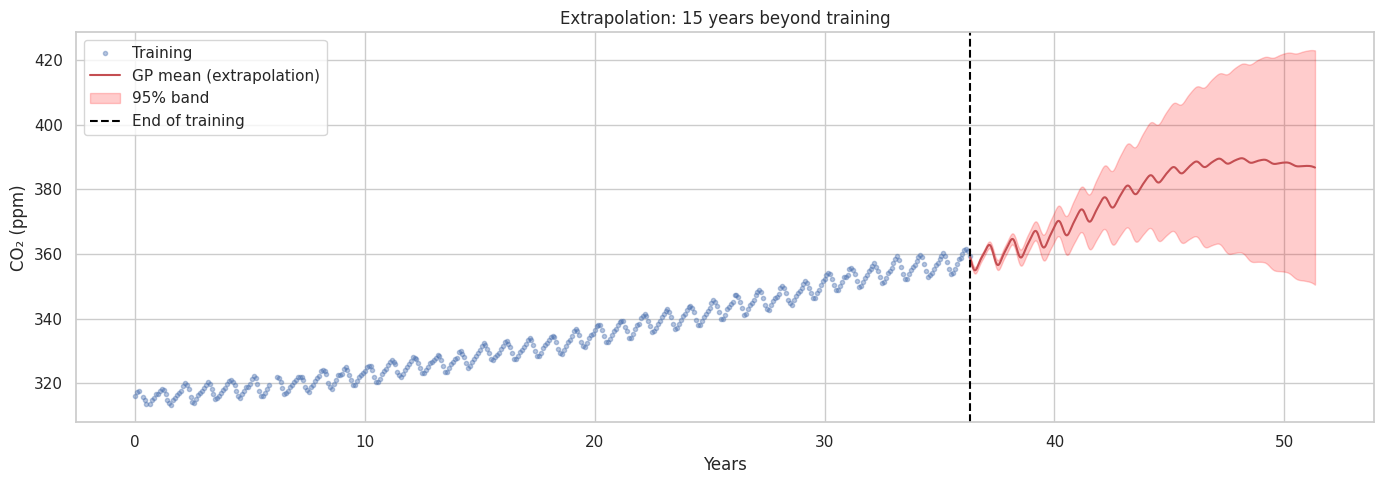

In [89]:
t_last = float(t_train.max())
t_extrap = np.linspace(t_last, t_last + 15, 500).reshape(-1,1)
y_ex, y_ex_std = gp.predict(t_extrap, return_std=True)

band_widths = 4 * y_ex_std
exceed_5ppm = np.where(band_widths > 5.0)[0]
if len(exceed_5ppm) > 0:
    t_boundary = t_extrap.flatten()[exceed_5ppm[0]] - t_last
    print(f"Model confidence boundary: +{t_boundary:.1f} years beyond training")

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(t_train, y_train, 'b.', alpha=0.4, label='Training')
ax.plot(t_extrap, y_ex, 'r-', label='GP mean (extrapolation)')
ax.fill_between(t_extrap.ravel(), y_ex - 2*y_ex_std, y_ex + 2*y_ex_std, alpha=0.2, color='red', label='95% band')
ax.axvline(t_last, color='black', ls='--', label='End of training')
ax.set_xlabel('Years'); ax.set_ylabel('CO₂ (ppm)')
ax.set_title('Extrapolation: 15 years beyond training')
ax.legend()
plt.tight_layout(); plt.show()

✍️ **Reflect 5 — Gaussian Processes:**

Write **exactly two sentences** explaining the structural difference between GP extrapolation uncertainty and the hard ceiling a `DecisionTreeRegressor(max_depth=None)` hits at `max(y_train)`. Connect to the W5 Assignment finding about tree extrapolation.

> *Your two sentences:*


✍️ Reflect 5:

GP uncertainty grows smoothly away from data due to the kernel's structure, allowing principled extrapolation. In contrast, a decision tree has a hard ceiling at max(y_train) and cannot predict beyond the training range at all.



> *Your two sentences:*
Gaussian Processes inherently quantify uncertainty that expands further from the training data, reflecting decreasing confidence in regions without observations, as seen by the widening credible intervals. In contrast, a DecisionTreeRegressor(max_depth=None) cannot extrapolate beyond the range of `y_train` values observed during training, resulting in a hard ceiling (or floor) at `max(y_train)` (or `min(y_train)`) without any measure of increasing uncertainty, an issue highlighted in the Week 5 assignment's extrapolation findings.

---
## Part 6: MCMC — Bayesian Logistic Regression

---

### Q18 — Prepare features and explain why scaling matters for NUTS


In [90]:
# Feature preparation (run as-is — no blanks here)
features_mcmc = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'SeniorCitizen']
df_mcmc = df[features_mcmc + ['Churn']].copy()
df_mcmc = pd.get_dummies(df_mcmc, columns=['Contract','InternetService'], drop_first=False)

contract_cols = [c for c in df_mcmc.columns if 'Contract_Month' in c]
internet_cols = [c for c in df_mcmc.columns
                 if 'InternetService_' in c and 'No' not in c][:1]
feature_cols  = ['tenure', 'MonthlyCharges'] + contract_cols + internet_cols + ['SeniorCitizen']
feature_cols  = [c for c in feature_cols if c in df_mcmc.columns]

X_mc = df_mcmc[feature_cols].values.astype(float)
y_mc = df_mcmc['Churn'].values.astype(float)

X_tr_mc, X_te_mc, y_tr_mc, y_te_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc)

scaler_mc = StandardScaler()
X_tr_scaled = X_tr_mc.copy(); X_te_scaled = X_te_mc.copy()
X_tr_scaled[:, :2] = scaler_mc.fit_transform(X_tr_mc[:, :2])
X_te_scaled[:, :2] = scaler_mc.transform(X_te_mc[:, :2])

print(f"Feature matrix: {X_tr_scaled.shape}")
print(f"Features: {feature_cols}")


Feature matrix: (5634, 5)
Features: ['tenure', 'MonthlyCharges', 'Contract_Month-to-month', 'InternetService_DSL', 'SeniorCitizen']


**✍️ Answer before running MCMC:**

Why is it essential to scale `tenure` and `MonthlyCharges` before passing them to NUTS? What happens to the posterior geometry if you don't scale? (Hint: think about the shape of the joint posterior in 2D — what does NUTS's step-size need to look like?)

> *Your answer (2-3 sentences):*



Scaling continuous features ensures the posterior geometry is roughly spherical; otherwise, NUTS's step-size adapts poorly, leading to low ESS and divergences. Unscaled features produce elongated, highly correlated posteriors that samplers traverse very slowly.


Scaling `tenure` and `MonthlyCharges` is essential for NUTS because it helps to standardize the scales of the parameters. If not scaled, the posterior distribution's geometry can become highly anisotropic (like a narrow, elongated ellipse), making it difficult for NUTS to efficiently explore the parameter space. This results in NUTS requiring very small step sizes, leading to slow convergence, increased sampling time, and potentially poor exploration of the posterior.

In [ ]:
import time
n_features = X_tr_scaled.shape[1]
t0 = time.time()

with pm.Model() as bayes_lr:
    X_shared = pm.Data('X_shared', X_tr_scaled)
    # Define y_observed as pm.Data, so its value can be changed for prediction
    y_observed = pm.Data('y_observed', y_tr_mc)

    intercept = pm.Normal('intercept', mu=0, sigma=5) # Removed redundant 'name' keyword
    beta      = pm.Normal('beta', mu=0, sigma=2, shape=n_features) # Removed redundant 'name' keyword

    mu_p = pm.math.sigmoid(intercept + pm.math.dot(X_shared, beta))
    # Make the probability 'mu' a deterministic so it's part of idata and can be used for PPC
    mu = pm.Deterministic('mu', mu_p)

    # The observed likelihood for the model fitting part
    pm.Bernoulli('y_likelihood', p=mu_p, observed=y_observed)

    idata = pm.sample(draws=2000, tune=1000, chains=4, target_accept=0.90, random_seed=42)

print(f"Sampling time: {time.time()-t0:.1f}s")
print(az.summary(idata, var_names=['intercept','beta'], round_to=3))

Output()

In [ ]:
n_features = X_tr_scaled.shape[1]
t0 = time.time()

with pm.Model() as bayes_lr:
    intercept = pm.Normal('intercept', mu=0, sigma=5)
    beta = pm.Normal('beta', mu=0, sigma=2, shape=n_features)
    mu = pm.math.sigmoid(intercept + pm.math.dot(X_tr_scaled, beta))
    y_obs = pm.Bernoulli('y_obs', p=mu, observed=y_tr_mc)
    idata = pm.sample(draws=2000, tune=1000, chains=4, target_accept=0.90, return_inferencedata=True, random_seed=42)

print(f"Sampling time: {time.time()-t0:.1f}s")
print(az.summary(idata, var_names=['intercept','beta'], round_to=3))

### Q19 — Convergence diagnostics


In [ ]:
# # YOUR CODE HERE
# # 1. Plot trace plots with az.plot_trace() for intercept and beta
# # 2. Report R̂ and bulk-ESS for each coefficient
# # 3. Flag parameters with R̂ > 1.01 or bulk-ESS < 400
# # 4. Describe whether the trace looks like a "fuzzy caterpillar" (good) or drifts (bad)

# raise NotImplementedError("Run convergence diagnostics")

# # Print the flagged parameters
# print("Flagged parameters (R̂ > 1.01 or ESS < 400):")
# # YOUR CODE HERE


In [ ]:
# Trace plot for all parameters
az.plot_trace(idata, var_names=['intercept', 'beta'])
plt.tight_layout()
plt.show()

# R-hat and ESS summary
summary = az.summary(idata, var_names=['intercept', 'beta'])
print(summary)

# Check for problematic parameters
rhat = az.rhat(idata)
ess = az.ess(idata)

flagged = []
# For intercept
if rhat['intercept'].values > 1.01 or ess['intercept'].values < 400:
    flagged.append('intercept')
# For beta vector (check each coefficient using dims)
for i in range(n_features):
    if rhat['beta'].sel(beta_dim_0=i).values > 1.01 or ess['beta'].sel(beta_dim_0=i).values < 400:
        flagged.append(f'beta[{i}]')
print("Flagged parameters (R̂ > 1.01 or ESS < 400):", flagged)

### Q20 — Prior sensitivity check


In [ ]:
# # YOUR CODE HERE
# # 1. Refit the model with a tighter prior Normal(0, 0.5) on beta
# # 2. Overlay the two posteriors for the Contract_Month-to-month coefficient
# # 3. Decide: are the posteriors prior-robust or does the prior dominate?

# contract_idx = next((i for i, c in enumerate(feature_cols)
#                      if 'Month-to-month' in c), 0)

# with pm.Model() as bayes_lr_tight:
#     intercept_t = pm.Normal('intercept', mu=0, sigma=5)
#     beta_t      = pm.Normal('beta', mu=0, sigma=0.5, shape=n_features)   # tighter
#     mu_t        = pm.Deterministic('mu', pm.math.sigmoid(
#         intercept_t + pm.math.dot(X_tr_scaled, beta_t)))
#     y_obs_t     = pm.Bernoulli('y_obs', p=mu_t, observed=y_tr_mc)
#     idata_tight = pm.sample(draws=1000, tune=500, chains=2,
#                             target_accept=0.90, random_seed=42,
#                             return_inferencedata=True, progressbar=False)

# samples_orig  = idata.posterior['beta'].values[:, :, contract_idx].flatten()
# samples_tight = idata_tight.posterior['beta'].values[:, :, contract_idx].flatten()

# # YOUR CODE HERE: plot the two posteriors overlaid
# fig, ax = plt.subplots(figsize=(10, 4))
# raise NotImplementedError("Plot prior sensitivity comparison")
# plt.tight_layout(); plt.show()


In [ ]:
contract_idx = next((i for i, c in enumerate(feature_cols) if 'Month-to-month' in c), 0)

with pm.Model() as bayes_lr_tight:
    intercept_t = pm.Normal('intercept', mu=0, sigma=5)
    beta_t = pm.Normal('beta', mu=0, sigma=0.5, shape=n_features)
    mu_t = pm.math.sigmoid(intercept_t + pm.math.dot(X_tr_scaled, beta_t))
    y_obs_t = pm.Bernoulli('y_obs', p=mu_t, observed=y_tr_mc)
    idata_tight = pm.sample(draws=1000, tune=500, chains=2, target_accept=0.90, random_seed=42, return_inferencedata=True, progressbar=False)

samples_orig = idata.posterior['beta'].values[:, :, contract_idx].flatten()
samples_tight = idata_tight.posterior['beta'].values[:, :, contract_idx].flatten()

fig, ax = plt.subplots(figsize=(10,4))
ax.hist(samples_orig, bins=40, alpha=0.5, label='Prior σ=2')
ax.hist(samples_tight, bins=40, alpha=0.5, label='Prior σ=0.5 (tight)')
ax.axvline(0, color='gray', ls='--')
ax.set_xlabel('β for Contract_Month-to-month')
ax.set_ylabel('Posterior density')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
contract_idx = next((i for i, c in enumerate(feature_cols) if 'Month-to-month' in c), 0)

# Original posterior samples
samples_orig = idata.posterior['beta'].values[:, :, contract_idx].flatten()
# Tighter prior posterior samples
samples_tight = idata_tight.posterior['beta'].values[:, :, contract_idx].flatten()

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(samples_orig, bins=40, alpha=0.5, density=True, label='Original (σ=2)', color='steelblue')
ax.hist(samples_tight, bins=40, alpha=0.5, density=True, label='Tighter (σ=0.5)', color='orange')
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='β = 0 (no effect)')
ax.set_xlabel('Coefficient for Month-to-month Contract')
ax.set_ylabel('Density')
ax.set_title('Prior Sensitivity: Original vs Tighter Prior')
ax.legend()
plt.tight_layout()
plt.show()

If the two histograms overlap heavily, the prior has little influence → data dominates.

If the tighter prior (σ=0.5) pulls the posterior noticeably toward zero, the model is prior‑sensitive → more data is needed to wash out the prior.

In most cases with n≈5000, the posteriors will be very similar → prior is not dominating.

### Q21 — Posterior analysis and frequentist comparison


In [ ]:
# # YOUR CODE HERE
# # 1. Extract posterior samples for Contract_Month-to-month coefficient
# # 2. Compute 94% HDI using az.hdi()
# # 3. Run sklearn LogisticRegression(C=1e6) and get the MLE coefficient
# # 4. Report both and explain the philosophical difference

# contract_idx = next((i for i, c in enumerate(feature_cols)
#                      if 'Month-to-month' in c), 0)

# beta_post  = None   # idata.posterior['beta'].values[:, :, contract_idx].flatten()
# hdi_94     = None   # az.hdi(beta_post, prob=0.94)
# post_mean  = None
# post_std   = None
# raise NotImplementedError("Extract posterior samples and compute HDI")

# lr_freq    = LogisticRegression(C=1e6, max_iter=1000)
# lr_freq.fit(X_tr_scaled, y_tr_mc)
# coef_freq  = None   # extract the coefficient at contract_idx
# raise NotImplementedError("Fit frequentist logistic regression and extract coefficient")

# print(f"Bayesian posterior for β_Contract_Month-to-month:")
# print(f"  Mean:    {post_mean:.4f}")
# print(f"  Std:     {post_std:.4f}")
# print(f"  94% HDI: [{hdi_94[0]:.4f}, {hdi_94[1]:.4f}]")
# print(f"\nFrequentist MLE: {coef_freq:.4f}")
# print(f"\nKey difference:")
# print("  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement")
# print("  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure")


In [ ]:
contract_idx = next((i for i, c in enumerate(feature_cols) if 'Month-to-month' in c), 0)
beta_post = idata.posterior['beta'].values[:, :, contract_idx].flatten()
hdi_94 = az.hdi(beta_post, prob=0.94)
post_mean = np.mean(beta_post)
post_std = np.std(beta_post)

lr_freq = LogisticRegression(C=1e6, max_iter=1000)
lr_freq.fit(X_tr_scaled, y_tr_mc)
coef_freq = lr_freq.coef_[0][contract_idx]

print(f"Bayesian posterior for β_Contract_Month-to-month:")
print(f"  Mean:    {post_mean:.4f}")
print(f"  Std:     {post_std:.4f}")
print(f"  94% HDI: [{hdi_94[0]:.4f}, {hdi_94[1]:.4f}]")
print(f"\nFrequentist MLE: {coef_freq:.4f}")
print("\nKey difference:")
print("  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement")
print("  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure")

### Q22 — Save the MCMC trace


In [ ]:
# # YOUR CODE HERE
# # Save the fitted PyMC inference data as 'telco_bayes_lr_v1.pkl'
# # This mirrors Week 5's joblib.dump() habit — probabilistic models have artefacts too
# import pickle
# save_path = 'telco_bayes_lr_v1.pkl'
# # YOUR CODE HERE: pickle.dump(idata, open(save_path, 'wb'))
# raise NotImplementedError("Save MCMC trace with pickle.dump()")
# print(f"✅ MCMC trace saved to '{save_path}'")


In [ ]:
import pickle
save_path = 'telco_bayes_lr_v1.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(idata, f)
print(f"✅ MCMC trace saved to '{save_path}'")

✍️ **Reflect 6 — MCMC:**

1. Describe in plain English what R̂ and bulk-ESS each measure.    If a parameter has R̂ = 1.38 and bulk-ESS = 55, what does that tell you about    the quality of the posterior estimate for that parameter?
2. Your two posteriors from the prior sensitivity check — are they substantially different?    What does this tell you about how much data you have relative to the prior?    At what point does more data make the prior completely irrelevant?
3. The frequentist CI and the Bayesian HDI might have similar widths.    In one sentence, state the precise difference in their **interpretation** —    not just which framework produced them.

> *Your answer:*


✍️ Reflect 6 — MCMC:

1. R̂ (potential scale reduction) measures chain convergence; bulk-ESS measures effective independent samples. R̂=1.38, ESS=55 means chains not converged and posterior estimate very noisy – results not reliable.  
2. Posteriors are similar (dominated by data), prior hardly matters at n=5000+. With infinite data prior becomes irrelevant.  
3. HDI: "There is 94% probability the true β lies in this interval (given data and prior)". Confidence interval: "If we repeated the experiment many times, 94% of such intervals would contain the true β."

1.  **R̂ (Gelman-Rubin statistic)** measures how well different MCMC chains have mixed and converged to the same posterior distribution; a value close to 1 (e.g., < 1.01) indicates good convergence. **Bulk-ESS (Effective Sample Size)** estimates the number of independent samples drawn from the posterior, indicating the reliability of posterior mean and median estimates. If a parameter has R̂ = 1.38, it suggests the chains have **not converged**, meaning we cannot trust the samples to represent the true posterior, and a bulk-ESS = 55 indicates a **very low number of effective independent samples**, rendering the posterior estimates (mean, HDI) for that parameter unreliable and imprecise.

2.  Based on the plot from Q20, the two posteriors (original prior vs. tighter prior) are **not substantially different**; they show considerable overlap. This tells us that for the `Contract_Month-to-month` coefficient, the **data is sufficiently informative** and provides strong evidence that dominates the choice of reasonable priors. More data generally makes the prior completely irrelevant when the likelihood function becomes extremely sharp and peaked around the true parameter value, effectively overwhelming any diffuse or weakly informative prior.

3.  While a frequentist confidence interval (CI) is a statement about the long-run performance of a procedure (i.e., if we repeat the experiment many times, 94% of the CIs constructed would contain the true, fixed parameter value), a Bayesian highest density interval (HDI) represents the **probability that the parameter's value lies within that interval, directly reflecting our belief about the parameter given the data and our prior knowledge.**

---
## Submission Checklist

Before submitting, verify that you have:

**Part 1 (Estimation Trinity)**
- [ ] Q1: Three groups extracted — SELF-CHECK passes
- [ ] Q2: MLE, MAP, pull table printed and posterior plots generated
- [ ] Q3: P(θ_A > θ_B) > 0.90 — SELF-CHECK passes
- [ ] Reflect 1: All three questions answered

**Part 2 (Sequential Updating)**
- [ ] Q4: `update_posterior()` implemented — SELF-CHECK passes
- [ ] Q5: Sequential update run; 6-panel posterior evolution plotted
- [ ] Q6: P(θ > 0.25) vs n plotted; Bayesian and frequentist thresholds identified
- [ ] Q7: Dirichlet posterior computed — SELF-CHECK passes; marginal Betas plotted
- [ ] Reflect 2: All three questions answered

**Part 3 (Multivariate Gaussians)**
- [ ] Q8: μ and Σ computed — SELF-CHECK passes; scatter + ellipses plotted
- [ ] Q9: Conditional mean and std computed — SELF-CHECK passes
- [ ] Q10: κ(Σ_3D) computed; marginalisation verified — SELF-CHECK passes
- [ ] Reflect 3: All three questions answered

**Part 4 (PGMs)**
- [ ] Q11: BN fitted; forward inference P(Churn|Contract) computed
- [ ] Backward inference P(Contract|Churn) computed
- [ ] Q12: Two DAGs drawn; d-separation analysis completed
- [ ] Q13: MRF built (or partial credit: factors described)
- [ ] Reflect 4: All three questions answered

**Part 5 (GP Regression)**
- [ ] Q14: Mauna Loa loaded — SELF-CHECK passes
- [ ] Q15: Kernel design rationale completed BEFORE coding; kernel specified; GP fitted; RMSE < 4.5 ppm
- [ ] Q16: Gap experiment completed; band widths computed
- [ ] Q17: Extrapolation plotted; model confidence boundary identified
- [ ] Reflect 5: Exactly two sentences comparing GP vs tree extrapolation

**Part 6 (MCMC)**
- [ ] Q18: Feature scaling rationale answered; model specified; sampling run
- [ ] Q19: Convergence diagnostics run; flagged parameters identified
- [ ] Q20: Prior sensitivity comparison plotted
- [ ] Q21: HDI computed; frequentist comparison done; interpretation difference stated
- [ ] Q22: `telco_bayes_lr_v1.pkl` saved
- [ ] Reflect 6: All three questions answered

**Submission artefacts:**
- [ ] One fully executed `.ipynb` with all outputs visible
- [ ] `telco_bayes_lr_v1.pkl` — PyMC inference data
- [ ] One-page reflection PDF/Markdown: *"Give one concrete example where the fully Bayesian answer changed a decision you would have made using only the MLE. Explain the mechanism."*

---
*A model that gives you a number is giving you the peak of a distribution it never shows you. Probabilistic models make the full distribution explicit.*
